In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import statsmodels.api as sm

# Dataset

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/eduardofc/data/refs/heads/main/breast_cancer_data.csv")
df = df[['radius_mean', 'texture_mean', 'smoothness_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_mean', 'diagnosis']]
df.head()

,radius_mean,texture_mean,smoothness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,diagnosis
0,17.99,10.38,0.11840,0.3001,0.2419,0.07871,M
1,20.57,17.77,0.08474,0.0869,0.1812,0.05667,M
2,19.69,21.25,0.10960,0.1974,0.2069,0.05999,M
3,11.42,20.38,0.14250,0.2414,0.2597,0.09744,M
4,20.29,14.34,0.10030,0.1980,0.1809,0.05883,M


In [3]:
df.shape
df.dtypes
df.isna().sum()
df.describe()

,radius_mean,texture_mean,smoothness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,0.096360,0.088799,0.181162,0.062798
std,3.524049,4.301036,0.014064,0.079720,0.027414,0.007060
min,6.981000,9.710000,0.052630,0.000000,0.106000,0.049960
25%,11.700000,16.170000,0.086370,0.029560,0.161900,0.057700
50%,13.370000,18.840000,0.095870,0.061540,0.179200,0.061540
75%,15.780000,21.800000,0.105300,0.130700,0.195700,0.066120
max,28.110000,39.280000,0.163400,0.426800,0.304000,0.097440


In [4]:
num_cols = ['radius_mean', 'texture_mean', 'smoothness_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_mean']

# Plots

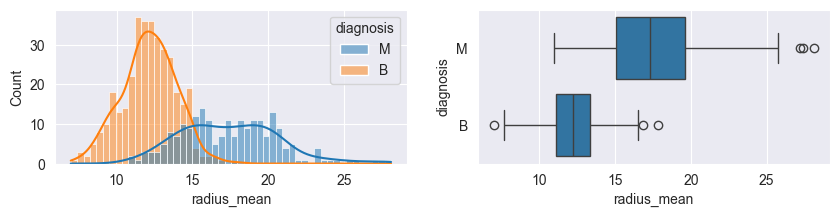

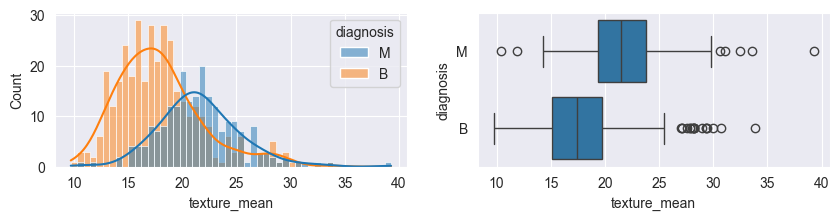

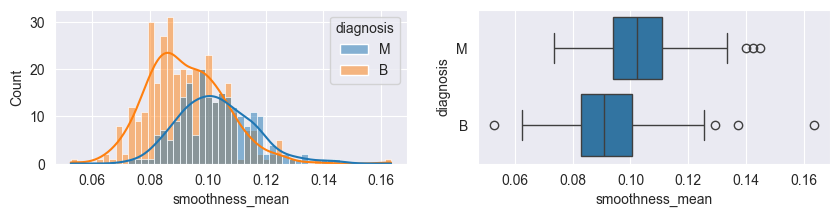

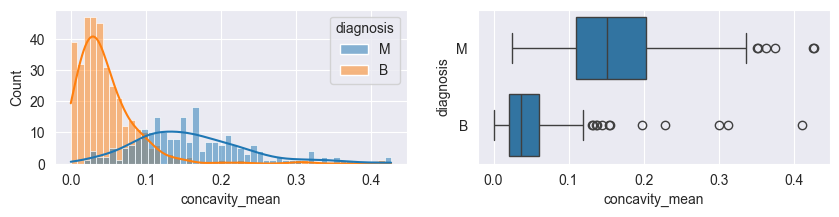

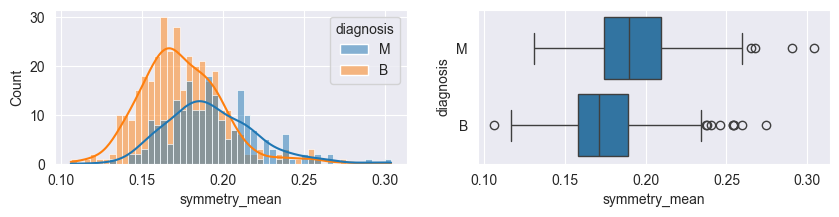

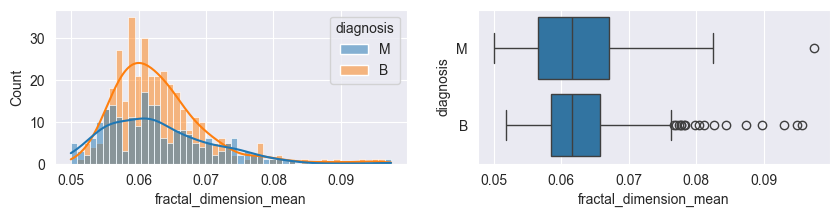

In [5]:
for feature in num_cols:
    plt.figure(figsize=(10,2))
    plt.subplot(1,2,1)
    sns.histplot(data=df, x=feature, kde=True, bins=50, hue="diagnosis")
    plt.subplot(1,2,2)
    sns.boxplot(data=df, x=feature, y="diagnosis")
    plt.show()
    # break

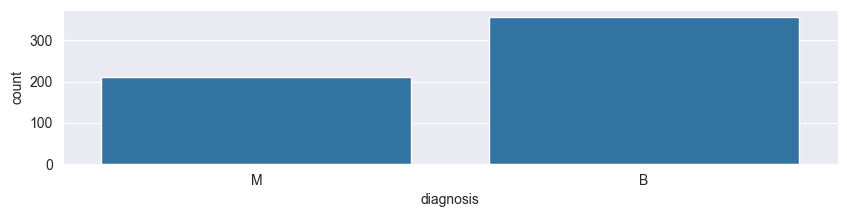

In [6]:
# para las categoricas
plt.figure(figsize=(10,2))
sns.countplot(data=df, x="diagnosis")
plt.show()

# Multicolinealidad

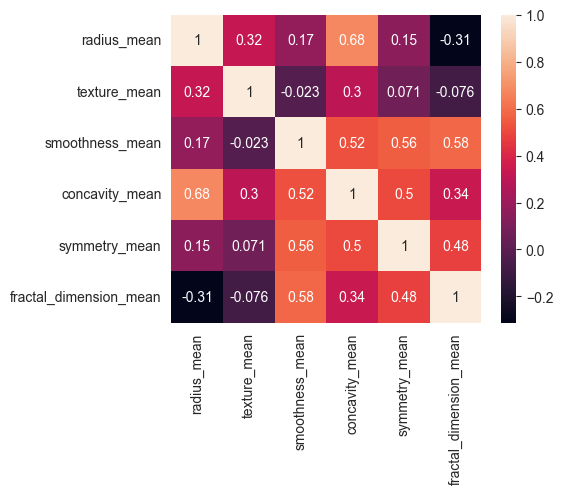

In [7]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns='diagnosis')
X = sm.add_constant(X)

for ii, col in enumerate(X.columns):
    vif = variance_inflation_factor(X.values, ii)
    print(f"{col}: {vif:.2f}")

# < 5, aceptables

const: 468.97
radius_mean: 4.90
texture_mean: 1.17
smoothness_mean: 2.13
concavity_mean: 5.14
symmetry_mean: 1.68
fractal_dimension_mean: 3.72


# Regresión logística múltiple

In [9]:
X = df.drop(columns='diagnosis')
X = sm.add_constant(X)
y = df["diagnosis"]  # esto hay que convertirlo a números
y = df["diagnosis"].map({'M': 1, 'B': 0})

model = sm.Logit(y, X)
results = model.fit()
results.summary()

Optimization terminated successfully.
         Current function value: 0.137639
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      562
Method:                           MLE   Df Model:                            6
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.7916
Time:                        08:04:51   Log-Likelihood:                -78.316
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                3.075e-125
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -34.0618      6.016     -5.662      0.000     -45.852     -22.272
radius_mean                1.1314      0.182      6.210      0.000       0.774       1.489
texture_mean               0.3808      0.062      6.127      0.000       0.259       0.503
smoothness_mean          120.3627     25.046      4.806      0.000      71.273     169.452
concavity_mean            25.7575      5.880      4.380      0.000      14.232      37.283
symmetry_mean             16.2765     10.929      1.489      0.136      -5.143      37.696
fractal_dimension_mean  -110.3520     61.296     -1.800      0.072    -230.491       9.787
==========================================================================================

Possibly complete quasi-separation: A fraction 0.17 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [10]:
# eliminamos symetry mean

X = df.drop(columns=['diagnosis', 'symmetry_mean'])
X = sm.add_constant(X)
y = df["diagnosis"].map({'M': 1, 'B': 0})

model = sm.Logit(y, X)
results = model.fit()
results.summary()

Optimization terminated successfully.
         Current function value: 0.139603
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      563
Method:                           MLE   Df Model:                            5
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.7886
Time:                        08:04:51   Log-Likelihood:                -79.434
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                8.144e-126
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -32.7312      5.798     -5.645      0.000     -44.095     -21.368
radius_mean                1.1225      0.179      6.265      0.000       0.771       1.474
texture_mean               0.3734      0.061      6.093      0.000       0.253       0.494
smoothness_mean          132.2116     24.297      5.441      0.000      84.590     179.833
concavity_mean            27.1612      5.695      4.769      0.000      15.999      38.323
fractal_dimension_mean  -100.3746     59.398     -1.690      0.091    -216.793      16.044
==========================================================================================

Possibly complete quasi-separation: A fraction 0.17 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

# Odd ratios

In [11]:
results.conf_int()
results.params
results.pvalues

const                     1.647749e-08
radius_mean               3.739575e-10
texture_mean              1.104762e-09
smoothness_mean           5.284743e-08
concavity_mean            1.847362e-06
fractal_dimension_mean    9.105567e-02
dtype: float64

In [12]:
conf = results.conf_int()
conf.columns = ["IC_inf_log", "IC_sup_log"]

df_results = pd.DataFrame({
    "Coef (log-odds)": results.params,
    "OR": np.exp(results.params),
    "IC_inf": np.exp(conf["IC_inf_log"]),
    "IC_sup": np.exp(conf["IC_sup_log"]),
    "p-valor": results.pvalues
})
df_results = df_results.drop("const")
df_results.round(3)

,Coef (log-odds),OR,IC_inf,IC_sup,p-valor
radius_mean,1.123,3.073000e+00,2.163000e+00,4.366000e+00,0.000
texture_mean,0.373,1.453000e+00,1.288000e+00,1.638000e+00,0.000
smoothness_mean,132.212,2.622866e+57,5.458042e+36,1.260420e+78,0.000
concavity_mean,27.161,6.250856e+11,8.881645e+06,4.399321e+16,0.000
fractal_dimension_mean,-100.375,0.000000e+00,0.000000e+00,9.286022e+06,0.091


In [13]:
# Por cada unidad que aumente el radio promedio de las células, las probabilidades (odds) de que el tumor sea maligno se multiplican por 3.07
# si smoothness sube 1 unidad entera, el OR es 132"... pero subir 1 unidad entera es imposible en esa variable
# porque varia entre 0.05 a 0.16.
# leccion aprendida, Variables en centésimas explotan

# Normalizar

## Min Max

In [14]:
df2 = df[num_cols].copy()

for col in df2.columns:
    col_min = df2[col].min()
    col_max = df2[col].max()
    df2[col] = (df2[col] - col_min) / (col_max - col_min)

df2['diagnosis'] = df['diagnosis']
df2.head()

,radius_mean,texture_mean,smoothness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,diagnosis
0,0.521037,0.022658,0.593753,0.703140,0.686364,0.605518,M
1,0.643144,0.272574,0.289880,0.203608,0.379798,0.141323,M
2,0.601496,0.390260,0.514309,0.462512,0.509596,0.211247,M
3,0.210090,0.360839,0.811321,0.565604,0.776263,1.000000,M
4,0.629893,0.156578,0.430351,0.463918,0.378283,0.186816,M


In [15]:
X = df2.drop(columns=['diagnosis', 'symmetry_mean'])
X = sm.add_constant(X)
y = df2["diagnosis"].map({'M': 1, 'B': 0})

model = sm.Logit(y, X)
results = model.fit()
results.summary()

Optimization terminated successfully.
         Current function value: 0.139603
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      563
Method:                           MLE   Df Model:                            5
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.7886
Time:                        08:04:52   Log-Likelihood:                -79.434
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                8.144e-126
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -19.3254      2.424     -7.971      0.000     -24.077     -14.573
radius_mean               23.7181      3.786      6.265      0.000      16.297      31.139
texture_mean              11.0416      1.812      6.093      0.000       7.490      14.593
smoothness_mean           14.6451      2.691      5.441      0.000       9.370      19.920
concavity_mean            11.5924      2.431      4.769      0.000       6.829      16.356
fractal_dimension_mean    -4.7658      2.820     -1.690      0.091     -10.293       0.762
==========================================================================================

Possibly complete quasi-separation: A fraction 0.17 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [16]:
conf = results.conf_int()
conf.columns = ["IC_inf_log", "IC_sup_log"]

df_results = pd.DataFrame({
    "Coef (log-odds)": results.params,
    "OR": np.exp(results.params),
    "IC_inf": np.exp(conf["IC_inf_log"]),
    "IC_sup": np.exp(conf["IC_sup_log"]),
    "p-valor": results.pvalues
})
df_results = df_results.drop("const")
df_results.round(3)

,Coef (log-odds),OR,IC_inf,IC_sup,p-valor
radius_mean,23.718,1.998146e+10,1.196467e+07,3.336979e+13,0.000
texture_mean,11.042,6.241879e+04,1.790224e+03,2.176323e+06,0.000
smoothness_mean,14.645,2.292334e+06,1.173172e+04,4.479134e+08,0.000
concavity_mean,11.592,1.082697e+05,9.238830e+02,1.268811e+07,0.000
fractal_dimension_mean,-4.766,9.000000e-03,0.000000e+00,2.142000e+00,0.091


## Standarize

In [17]:
df3 = df[num_cols].copy()

for col in df3.columns:
    col_mean = df3[col].mean()
    col_std = df3[col].std()
    df3[col] = (df3[col] - col_mean) / col_std

df3['diagnosis'] = df['diagnosis']
df3.head()

,radius_mean,texture_mean,smoothness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,diagnosis
0,1.096100,-2.071512,1.567087,2.650542,2.215566,2.253764,M
1,1.828212,-0.353322,-0.826235,-0.023825,0.001391,-0.867889,M
2,1.578499,0.455786,0.941382,1.362280,0.938859,-0.397658,M
3,-0.768233,0.253509,3.280667,1.914213,2.864862,4.906602,M
4,1.748758,-1.150804,0.280125,1.369806,-0.009552,-0.561956,M


In [18]:
X = df3.drop(columns=['diagnosis', 'symmetry_mean'])
X = sm.add_constant(X)
y = df3["diagnosis"].map({'M': 1, 'B': 0})

model = sm.Logit(y, X)
results = model.fit()
results.summary()

Optimization terminated successfully.
         Current function value: 0.139603
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      563
Method:                           MLE   Df Model:                            5
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.7886
Time:                        08:04:53   Log-Likelihood:                -79.434
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                8.144e-126
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0.8213      0.216     -3.803      0.000      -1.245      -0.398
radius_mean                3.9559      0.631      6.265      0.000       2.718       5.194
texture_mean               1.6060      0.264      6.093      0.000       1.089       2.123
smoothness_mean            1.8594      0.342      5.441      0.000       1.190       2.529
concavity_mean             2.1653      0.454      4.769      0.000       1.275       3.055
fractal_dimension_mean    -0.7087      0.419     -1.690      0.091      -1.531       0.113
==========================================================================================

Possibly complete quasi-separation: A fraction 0.17 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [19]:
conf = results.conf_int()
conf.columns = ["IC_inf_log", "IC_sup_log"]

df_results = pd.DataFrame({
    "Coef (log-odds)": results.params,
    "OR": np.exp(results.params),
    "IC_inf": np.exp(conf["IC_inf_log"]),
    "IC_sup": np.exp(conf["IC_sup_log"]),
    "p-valor": results.pvalues
})
df_results = df_results.drop("const")
df_results.round(3)

,Coef (log-odds),OR,IC_inf,IC_sup,p-valor
radius_mean,3.956,52.241,15.153,180.104,0.000
texture_mean,1.606,4.983,2.973,8.353,0.000
smoothness_mean,1.859,6.420,3.286,12.543,0.000
concavity_mean,2.165,8.717,3.580,21.223,0.000
fractal_dimension_mean,-0.709,0.492,0.216,1.120,0.091


# Métricas

In [27]:
from sklearn.metrics import *

## Confusion matrix


In [21]:
results.pred_table()

array([[347.,  10.],
       [ 20., 192.]])

In [ ]:
y_hat_probs = results.predict(X)

# umbral 0.5
y_hat = (y_hat_probs >= 0.5).astype(int)

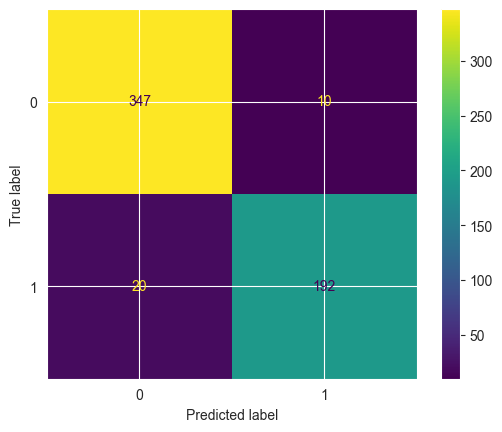

In [36]:
cm = confusion_matrix(y_true=y, y_pred=y_hat)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    # display_labels=['B','M']
)
disp.plot()
plt.show()

In [29]:
fpr, tpr, thresholds = roc_curve(y, y_hat_probs)
roc_auc = auc(fpr, tpr)

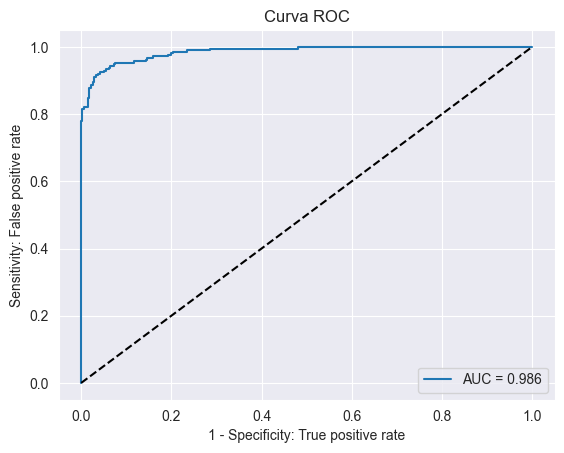

In [35]:
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('1 - Specificity: True positive rate')
plt.ylabel('Sensitivity: False positive rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [ ]:
# los resultados son casi perfectos, overfitting? leakage (no aplica)? desbalanceo? la target entre las features?

In [38]:
tn, fp, fn, tp = cm.ravel()

print(f"Accuracy:              {accuracy_score(y, y_hat):.4f}")
print(f"Precision:             {precision_score(y, y_hat):.4f}")
print(f"Recall (Sensibility):  {recall_score(y, y_hat):.4f}")
print(f"Specificity:           {tn / (tn + fp):.4f}")

Accuracy:              0.9473
Precision:             0.9505
Recall (Sensibility):  0.9057
Specificity:           0.9720


## Más específico

In [39]:
# ¿puedo modificar y_hat en funcion de las probabilidades?

y_hat_probs = results.predict(X)

# umbral 0.5
y_hat = (y_hat_probs >= 0.99).astype(int)

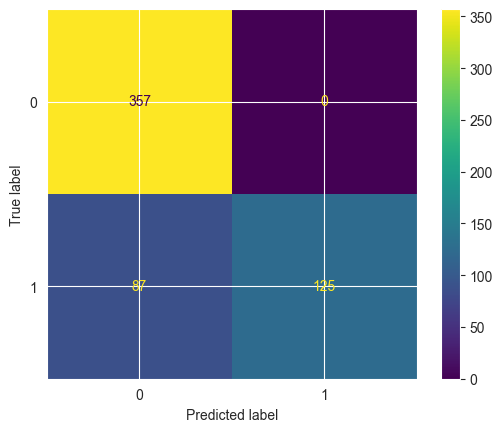

In [40]:
cm = confusion_matrix(y_true=y, y_pred=y_hat)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    # display_labels=['B','M']
)
disp.plot()
plt.show()

In [41]:
tn, fp, fn, tp = cm.ravel()

print(f"Accuracy:              {accuracy_score(y, y_hat):.4f}")
print(f"Precision:             {precision_score(y, y_hat):.4f}")
print(f"Recall (Sensibility):  {recall_score(y, y_hat):.4f}")
print(f"Specificity:           {tn / (tn + fp):.4f}")  # <- más específico

Accuracy:              0.8471
Precision:             1.0000
Recall (Sensibility):  0.5896
Specificity:           1.0000


## Más sensible

In [42]:
y_hat_probs = results.predict(X)

# umbral 0.5
y_hat = (y_hat_probs >= 0.1).astype(int)

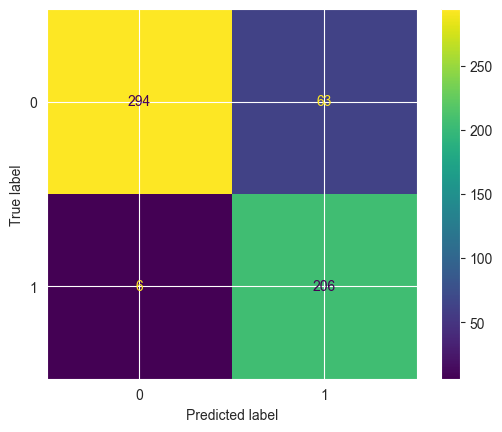

In [43]:
cm = confusion_matrix(y_true=y, y_pred=y_hat)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    # display_labels=['B','M']
)
disp.plot()
plt.show()

In [44]:
tn, fp, fn, tp = cm.ravel()

print(f"Accuracy:              {accuracy_score(y, y_hat):.4f}")
print(f"Precision:             {precision_score(y, y_hat):.4f}")
print(f"Recall (Sensibility):  {recall_score(y, y_hat):.4f}")# <- más sensible
print(f"Specificity:           {tn / (tn + fp):.4f}")

Accuracy:              0.8787
Precision:             0.7658
Recall (Sensibility):  0.9717
Specificity:           0.8235
